In [3]:
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

from deep_rc.constants import DF_MAIN_KEYS
from deep_rc.io_func.io import default_blob_writer, read_main_df
from deep_rc.lazyconfig import config

# from .base import Classifier
from deep_rc.model.base import Classifier 


In [4]:
print()

In [5]:
class UpsellModel(Classifier):
    def __init__(self):
        self.type_ = "upsell"
        self.model_type = f"{self.type_}_model"
        self.folder = self.model_type + f"{config.models_path}"
        self.target = "target_upsell"

        self.cat_predictors = ["industry", "payment_plan", "brand"]
        self.predictors = self.cat_predictors + [
            "active_extensions_created",
            "active_extensions_created_diff3",
            "active_extensions_created_diff6",
            "dls_per_employee",
            "use_mins_per_dl",
            "days_until_agreement_end",
            # "number_of_cases_started_this_month",
            # "number_of_cases_this_month",
            # "number_of_cases_started_this_month_per_dl",
            "number_of_cases_this_month_per_dl",
            # "median_case_duration",
            "case_severity_avg",
            "segment",
            "use_in_local_mins",
            "use_in_local_calls",
            "use_in_local_mins_diff",
            # "use_in_local_mins_mean",
            "use_in_local_calls_diff",
            # "use_in_local_calls_mean",
            "mrr",
            # "fax_total_mins",
            # "fax_ratio_in_mins",
            # "fax_total_calls",
            "fax_ratio_in_calls",
            # "fax_total_mins_diff",
            # "fax_total_mins_mean",
            # "fax_ratio_in_mins_diff",
            # "fax_ratio_in_mins_mean",
            # "fax_total_calls_diff",
            # "fax_total_calls_mean",
            # "fax_ratio_in_calls_diff",
            # "fax_ratio_in_calls_mean",
            "employees_to_ext_ratio",
            "num_dls",
            "glip_mau",
            "num_active_users",
            # "glip_mau_active_users_ratio",
            "glip_apps_api_calls",
            "sector",
            # "use_conf_mins",
            # "use_conf_calls",
            "use_conf_mins_diff",
            # "use_conf_mins_mean",
            "use_conf_calls_diff",
            # "use_conf_calls_mean",
            "use_in_tollfree_mins",
            "use_in_tollfree_calls",
            "use_in_tollfree_mins_diff",
            # "use_in_tollfree_mins_mean",
            "use_in_tollfree_calls_diff",
            # "use_in_tollfree_calls_mean",
            # "voice_total_mins",
            "voice_ratio_in_mins",
            "voice_total_calls",
            "voice_ratio_in_calls",
            # "voice_total_mins_diff",
            # "voice_total_mins_mean",
            # "voice_ratio_in_mins_diff",
            # "voice_ratio_in_mins_mean",
            "voice_total_calls_diff",
            # "voice_total_calls_mean",
            "voice_ratio_in_calls_diff",
            # "voice_ratio_in_calls_mean",
            "tenure",
            # "use_out_intl_mins",
            # "use_out_intl_calls",
            # "use_out_intl_mins_diff",
            # "use_out_intl_mins_mean",
            "use_out_intl_calls_diff",
            # "use_out_intl_calls_mean",
            # "total_cc_mrr",
            "has_cc",
            "additional_phone_numbers",
            "rcvm_package",
            # "rcvm_num_of_meetings",
            # "rcv_rcm_meetings_ratio",
            # "rcvm_num_participants",
            # "rcvm_mean_meeting_duration",
            # "rcvm_has_guests",
            # "rcvm_other_rc_customers",
            "use_mins_per_user",
            "num_active_users_diff6",
            # "num_signature_surveys",
            # "mrr_diff3",
            "num_dls_diff3",
            "num_dls_diff6",
            # "ultimate_parent_id",
            # "rcvm_num_of_meetings_diff_diff3",
            # "has_parent",
            # "num_resolved_relationship_cases",
            "employees_segments",
            "discount_change",
            # "percent_high_frequency_cases",
            # "csat",
            "total_cases",
            # "num_support_surveys",
            # "num_of_un_resolved_cases",
            # "three_months_num_resolved_new_customer_cases",
            # "avg_wait_time_until_initial_contact",
            # "num_resolved_signature_cases",
            # "total_cases_diff3",
            # "three_months_avg_ease_of_handling_issue",
            "mrr_per_dl",
            # "three_months_percent_satisfactory_resolution",
            # "rcvm_meetings_total_mins_per_dl",
            # "three_months_comments_sentiment_score",
            # "num_relationship_surveys",
            # "three_months_num_of_un_resolved_cases",
            # "avg_ease_of_handling_issue",
            # "has_csrt",
            # "three_months_num_support_surveys",
            # "three_months_num_relationship_surveys",
            # "avg_timeliness_of_the_incident_resolution",
            # "discount_pct_diff6",
            # "three_months_num_resolved_relationship_cases",
            # "percent_satisfactory_resolution",
            # "three_months_avg_wait_time_until_initial_contact",
            # "three_months_avg_timeliness_of_the_incident_resolution",
            # "avg_support_contact_frequency",
            # "discount_pct_diff3",
            # "rcvm_meetings_total_mins",
            # "three_months_num_resolved_support_cases",
            # "rcvm_num_of_meetings_diff_per_dl",
            # "num_of_cases_with_high_frequency",
            # "three_months_csat",
            "voice_total_mins_per_dl",
            # "three_months_avg_support_contact_frequency",
            # "has_sales_agreement",
            # "rcvm_num_of_meetings_per_dl",
            # "rcvm_num_of_meetings_diff_diff6",
            "rcvm_num_of_meetings_diff",
            # "use_out_intl_calls_per_dl",
            "cc_minutes_per_dl",
            # "three_months_num_signature_surveys",
            # "num_resolved_new_customer_cases",
            # "three_months_num_of_cases_with_high_frequency",
            # "mrr_diff6",
            # "three_months_num_new_customer_surveys",
            "voice_total_calls_per_dl",
            "num_active_users_diff3",
            "num_resolved_support_cases",
            "total_cases_per_dl",
            # "three_months_dsat",
            "peer_group",
            # "three_months_percent_high_frequency_cases",
            # "num_new_customer_surveys",
            # "cc_minutes",
            # "total_cases_diff6",
            # "three_months_max_wait_time_until_initial_contact",
            # "max_wait_time_until_initial_contact",
            "has_csm",
            "num_active_users_per_dl",
            # "three_months_num_resolved_signature_cases",
            # "dsat",
            # "discount_pct",
            # "num_of_paid_dls",
            # "num_of_provis_dls",
            "payment_method",
            "service_group",
            "sub_industry",
            "ratio_prov_paid_dls",
        ]

        super().__init__()

        
        
    def run(self):
        
        # with s3.open(
        #     f"data/df_main.pq", "rb"
        #     # f"{dir_data}/segments/ids_5000_above.parquet", "rb"
        # ) as f:
        #     data = pd.read_parquet(f)
        
        # data = self.read()
        
        data = self.read_data()
        self.run_model(data)
        self.run_plots()
        self.save_model(data)
        self.save_predictions()

        self.run_size_upsell_model(data)

        self.copy_to_history()

    def read_data(self):
        
        columns_to_read = DF_MAIN_KEYS + self.predictors + [self.target, "acct_status"]
        # df_all = read_main_df(columns=columns_to_read)
        
        with s3.open(
            f"data/df_main.pq", "rb"
            # f"{dir_data}/segments/ids_5000_above.parquet", "rb"
        ) as f:
            df_all = pd.read_parquet(f)
            
            
        df_all = self._pre_train_filters(df_all)

        df_all = adapt_types_to_model(df_all)
        print(df_all[self.target].value_counts(dropna=False))
        df_all[self.target] = df_all[self.target].fillna(0)

        df_all = fill_numeric_nan(df_all, fill_value=-999)

        # Truncate to keep the process from blowing up memory
        df_all = df_all.query(
            f"""year_month > '{(datetime.now()-relativedelta(months=30))}'"""
        ).reset_index()

        print("\nusing the following predictors in the model")
        print(self.predictors)

        all_columns = get_column_names_from_blob_parquet("df_main.pq")
        print("\nNOT using the following predictors in the model")
        print(set(all_columns).difference(set(self.predictors)))

        return df_all
        
    def _pre_train_filters(self, df):
        #     """Add filters to train/pred dataset before starting modelling"""
        df = super()._pre_train_filters(df)
        df = df[
            df.brand.str.contains("RingCentral") & (df.service_group != "Fax")
        ].reset_index(drop=True)
        filter_dl = df.num_dls > 0
        print(f"Removing num_dls = 0, {1 - filter_dl.mean():.1%} of rows")
        df = df[filter_dl]
        # df = super()._pre_train_filters(df)
        return df

    def run_size_upsell_model(self, data):
        """model outputs expected MRR move from num_dls and current mrr"""
        target_col = "target_mrr_upsell_pct"
        predictors = ["num_dls", "mrr"]

        df_mrr_upsell = read_main_df(columns=DF_MAIN_KEYS + [target_col])
        data = data.merge(df_mrr_upsell, on=DF_MAIN_KEYS, how="left", validate="1:1")

        train_indices = self.indices["train"]
        test_indices = self.indices["test"]
        pred_indices = self.indices["pred"]

        def filter_train(df: pd.DataFrame) -> pd.DataFrame:
            df = df[df["target_upsell"] == 1]
            df = df[np.isfinite(df.target_mrr_upsell_pct)]
            df = df[df.year_month.dt.year >= 2020]  # 2019 data not as reliable
            return df

        x_train = data[train_indices].pipe(filter_train)[predictors]
        y_train = (
            data[train_indices]
            .pipe(filter_train)[target_col]
            .clip(upper=config.upsell_model.SIZE_MAX_Y_TRAIN)  # set max value
        )

        dict_pickle = {
            "data": data,
            "train_indices": train_indices,
            "test_indices": test_indices,
            "pred_indices": pred_indices,
        }

        default_blob_writer(dict_pickle, f"{self.folder}/size_upsell.pkl")

        size_model_base = Pipeline(
            steps=[
                ("log", FunctionTransformer(np.log1p)),
                ("regression", LinearRegression()),
            ]
        )
        size_model = clone(size_model_base)
        size_model.fit(x_train, y_train)

        def predict_clip(model, data_):
            """predict size and cap to the min relative move"""
            # MIN_SIZE_PRED: 0.10  # cap model predictions
            # MAX_SIZE_PRED: 3
            return model.predict(data_).clip(
                min=config.upsell_model.MIN_SIZE_PRED,
                max=config.upsell_model.MAX_SIZE_PRED,
            )

        x_test = data[test_indices].pipe(filter_train)[predictors]
        y_test = data[test_indices].pipe(filter_train)[target_col]
        y_test_pred = predict_clip(size_model, x_test)

        mae_test = mean_absolute_error(y_test, y_test_pred)
        print(f"## size of upsell (MRR pct) test MAE: {mae_test:.2f}")
        df_test_result = pd.DataFrame({"true": y_test, "pred": y_test_pred})
        fig, ax = plt.subplots()
        df_test_result.plot(kind="scatter", x="true", y="pred", ax=ax)
        image_stream = BytesIO()
        fig.savefig(image_stream, format="png")
        default_blob_writer(image_stream, f"{self.folder}/plots/upsell_size_model.png")

        y_train_pred = predict_clip(size_model, x_train)
        mae_train = mean_absolute_error(y_train, y_train_pred)
        print(f"## size of upsell (MRR pct) train MAE: {mae_train:.2f}")

        if config[self.model_type].RETRAIN_MODEL:
            full_train_indices = self.indices["full_train"]
            x_full_train = data[full_train_indices].pipe(filter_train)[predictors]
            y_full_train = (
                data[full_train_indices]
                .pipe(filter_train)[target_col]
                .clip(upper=config.upsell_model.SIZE_MAX_Y_TRAIN)  # set max value
            )

            size_model = clone(size_model_base)
            size_model.fit(x_full_train, y_full_train)

            y_full_train_pred = predict_clip(size_model, x_full_train)

            mae_train = mean_absolute_error(y_full_train, y_full_train_pred)
            print(
                f"## RETRAIN_MODEL: size of upsell  (MRR pct) "
                f"train MAE: {mae_train:.2f}"
            )

        # predict
        pred = data[pred_indices][DF_MAIN_KEYS + predictors]

        y_pred = predict_clip(size_model, pred[predictors])
        pred["pred_size_mrr_pct"] = y_pred

        default_blob_writer(pred, f"{self.folder}/upsell_size_pred.pq")


def run_upsell_model():
    UpsellModel().run()


## Model Reproduce manually 

In [ ]:
with s3.open(
    f"data/df_main.pq", "rb"
) as f:
    parquet_file = pd.read_parquet(f)


In [35]:
parquet_file['year_month'].min()

Timestamp('2021-05-01 00:00:00')

In [10]:
parquet_file.shape

(26972250, 222)

In [11]:
parquet_file['acct_status'].value_counts(dropna=False)

acct_status
Paid             26446109
Disabled           254459
Suspended          169967
Canceled            33377
Trial (other)       29211
Not Confirmed       20639
Free                18460
Initial                28
Name: count, dtype: int64

## Keep Paid Accounts Only 

In [12]:
parquet_file = parquet_file.loc[parquet_file['acct_status']=='Paid']

## NOT removal RCCC/RCX at this moment 

In [15]:
parquet_file.loc[parquet_file['has_cc']==True, 'rc_account_id'].nunique()

3273

## Control Data used for training 

In [21]:
parquet_file['num_dls'].describe()

count    16221517.0
mean      16.083077
std      180.325264
min             0.0
25%             1.0
50%             2.0
75%             6.0
max         40004.0
Name: num_dls, dtype: Float64

In [22]:
parquet_file = parquet_file.loc[parquet_file['num_dls']>=1]

In [34]:
parquet_file['year_month'].describe()

count                         16193919
mean     2023-09-11 01:37:21.061894400
min                2021-05-01 00:00:00
25%                2022-08-01 00:00:00
50%                2023-10-01 00:00:00
75%                2024-11-01 00:00:00
max                2025-10-01 00:00:00
Name: year_month, dtype: object

In [37]:
def get_weight_by_year(data):
    """
    Do exponential decay so that data from a year ago is half as important
    formula N(t) = N0 * e^(-lambda * t)
    lambda = ln(2) / t_half_life
    """
    t_half_life = 1  # year
    lambda_ = np.log(2) / t_half_life  # in years
    weight_year_0 = 1
    years_before_pred = (data.year_month - data.year_month.max()).dt.days / 365
    weight_array = weight_year_0 * np.exp(lambda_ * years_before_pred)
    assert weight_array.max() <= weight_year_0, "Max weight should be 1"
    data["weight"] = weight_array
    return weight_array

In [38]:
import lightgbm as lgb


In [68]:
df = parquet_file.loc[parquet_file['year_month']>='2023-06-01']

In [69]:
df.shape

(9526792, 222)

In [70]:
df = df.loc[df['year_month']<='2025-10-01']

In [71]:
df['year_month'].nunique()

29

In [72]:
df['year_month'].value_counts(dropna=False)

year_month
2025-10-01    360650
2025-09-01    358813
2025-08-01    356637
2025-07-01    353837
2025-06-01    352318
2025-05-01    349758
2025-04-01    347778
2025-03-01    345763
2025-02-01    341648
2025-01-01    339096
2024-12-01    336316
2024-11-01    334462
2024-10-01    332661
2024-09-01    329911
2024-08-01    326637
2024-07-01    324442
2024-06-01    324277
2024-05-01    320990
2024-04-01    318424
2024-03-01    317265
2024-02-01    314202
2024-01-01    311971
2023-12-01    310516
2023-11-01    308571
2023-10-01    306720
2023-09-01    304766
2023-08-01    302145
2023-07-01    299201
2023-06-01    297017
Name: count, dtype: int64

In [73]:
# df_all = self._pre_train_filters(df_all)


In [74]:
# df_all = adapt_types_to_model(df_all)

print("Casting nullable dtypes to usable type")
type_mapping = {"Int64": "float", "boolean": "float", "Float64": "float"}
for type_from, type_to in type_mapping.items():
    cols = df.select_dtypes(type_from).columns
    df[cols] = df[cols].astype(type_to)

Casting nullable dtypes to usable type


In [75]:

# print(df_all[self.target].value_counts(dropna=False))
# df_all[self.target] = df_all[self.target].fillna(0)

# df_all = fill_numeric_nan(df_all, fill_value=-999)
fill_value=-999
# select numeric columns
print(f"filling null numeric values with {fill_value}")
numeric_columns = df.select_dtypes(include=["number"]).columns

# fill fill_value to all NaN
df[numeric_columns] = df[numeric_columns].fillna(fill_value)

filling null numeric values with -999


In [76]:
from sklearn.model_selection import GroupShuffleSplit

In [77]:
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)

In [78]:
pred_windows = 3 

In [79]:
df["num_dl_lagged"] = df.groupby("rc_account_id").num_dls.shift(pred_windows)

/tmp/ipykernel_177/1148517505.py:1 PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

In [82]:
# calculate relative and abs differences in dls
df["num_dl_diff"] = df["num_dls"] - df["num_dl_lagged"]
df["num_dl_rel_diff"] = (df["num_dl_diff"] / df["num_dl_lagged"]).fillna(0)

df["future_num_dl_rel_diff"] = df.groupby(
    "rc_account_id").num_dl_rel_diff.shift(-pred_windows)
df["future_num_dl_diff"] = df.groupby("rc_account_id").num_dl_diff.shift(-pred_windows)

/tmp/ipykernel_177/1108823203.py:2 PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_177/1108823203.py:3 PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_177/1108823203.py:5 PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_177/1108823203.py:7 PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

In [84]:
upsell_threshold_percent = 0.1
upsell_threshold_num = 0

In [85]:
# create target feature
df['dl_upsell_target'] = (
    (df["future_num_dl_rel_diff"] >= upsell_threshold_percent)
    & (df["future_num_dl_diff"] >= upsell_threshold_num)
).astype("Int64")


/tmp/ipykernel_177/3733711558.py:2 PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

In [86]:

# find accounts with churn dates
churned_acc = df[~df["churn_date"].isna()]["rc_account_id"]

# fill na with 0 for accounts which have churned
df.loc[
    (df["rc_account_id"].isin(churned_acc) & df['dl_upsell_target'].isna()),
    'dl_upsell_target',
] = 0


In [87]:
df['dl_upsell_target'].value_counts(dropna=False)

dl_upsell_target
0       9207921
1        318871
<NA>          0
Name: count, dtype: Int64

In [88]:
df['year_month'].describe()

count                          9526792
mean     2024-08-15 14:10:00.819754496
min                2023-06-01 00:00:00
25%                2024-01-01 00:00:00
50%                2024-09-01 00:00:00
75%                2025-04-01 00:00:00
max                2025-10-01 00:00:00
Name: year_month, dtype: object

In [89]:
df = df.loc[(df['year_month']>='2023-06-01')&(df['year_month']<='2025-10-01')]

In [90]:
df['dl_upsell_target'].value_counts(dropna=False)

dl_upsell_target
0       9207921
1        318871
<NA>          0
Name: count, dtype: Int64

In [91]:
df.loc[df['dl_upsell_target'].isnull()]

,rc_account_id,year_month,acct_status,active_extensions_created,additional_phone_numbers,additional_tf_quantity,total_bmw_used,brand,number_of_cases_started_this_month,number_of_cases_this_month,...,voice_out_mins_per_call_diff,voice_in_mins_per_call_diff,voice_drop_trigger,low_active_users,num_dl_lagged,num_dl_diff,num_dl_rel_diff,future_num_dl_rel_diff,future_num_dl_diff,dl_upsell_target


In [92]:
df.loc[df['rc_account_id'].isin([63422683004]), ['rc_account_id',  'year_month', 'num_dls', 'num_dl_lagged', 'num_dl_diff', 
                                             'num_dl_rel_diff', 'future_num_dl_rel_diff', 'future_num_dl_diff', 'dl_upsell_target' ]].tail(20)

,rc_account_id,year_month,num_dls,num_dl_lagged,num_dl_diff,num_dl_rel_diff,future_num_dl_rel_diff,future_num_dl_diff,dl_upsell_target


In [93]:
df = df.loc[df['dl_upsell_target'].notnull()]

In [95]:
df['dl_upsell_target'].describe()

count    9526792.0
mean      0.033471
std       0.179863
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            1.0
Name: dl_upsell_target, dtype: Float64

In [96]:
df['year_month'].describe()

count                          9526792
mean     2024-08-15 14:10:00.819754496
min                2023-06-01 00:00:00
25%                2024-01-01 00:00:00
50%                2024-09-01 00:00:00
75%                2025-04-01 00:00:00
max                2025-10-01 00:00:00
Name: year_month, dtype: object

In [97]:
weights = get_weight_by_year(df)

/tmp/ipykernel_177/652260637.py:13 PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

In [98]:
df.shape, weights.shape

((9526792, 229), (9526792,))

In [100]:
type(weights)

pandas.core.series.Series

In [101]:
df_weights = weights.to_frame(name="weight_train")
print(df_weights.shape)

(9526792, 1)


In [102]:
df = pd.concat([df, df_weights], axis = 1)

In [103]:
print([x for x in df.columns if 'weight' in x.lower()])

['weight', 'weight_train']


In [104]:
df.shape

(9526792, 230)

In [105]:
orig_cat_predictors = ["industry", "payment_plan", "brand"]
orig_predictors = orig_cat_predictors + [
            "active_extensions_created",
            "active_extensions_created_diff3",
            "active_extensions_created_diff6",
            "dls_per_employee",
            "use_mins_per_dl",
            "days_until_agreement_end",
            # "number_of_cases_started_this_month",
            # "number_of_cases_this_month",
            # "number_of_cases_started_this_month_per_dl",
            "number_of_cases_this_month_per_dl",
            # "median_case_duration",
            "case_severity_avg",
            "segment",
            "use_in_local_mins",
            "use_in_local_calls",
            "use_in_local_mins_diff",
            # "use_in_local_mins_mean",
            "use_in_local_calls_diff",
            # "use_in_local_calls_mean",
            "mrr",
            # "fax_total_mins",
            # "fax_ratio_in_mins",
            # "fax_total_calls",
            "fax_ratio_in_calls",
            # "fax_total_mins_diff",
            # "fax_total_mins_mean",
            # "fax_ratio_in_mins_diff",
            # "fax_ratio_in_mins_mean",
            # "fax_total_calls_diff",
            # "fax_total_calls_mean",
            # "fax_ratio_in_calls_diff",
            # "fax_ratio_in_calls_mean",
            "employees_to_ext_ratio",
            "num_dls",
            "glip_mau",
            "num_active_users",
            # "glip_mau_active_users_ratio",
            "glip_apps_api_calls",
            "sector",
            # "use_conf_mins",
            # "use_conf_calls",
            "use_conf_mins_diff",
            # "use_conf_mins_mean",
            "use_conf_calls_diff",
            # "use_conf_calls_mean",
            "use_in_tollfree_mins",
            "use_in_tollfree_calls",
            "use_in_tollfree_mins_diff",
            # "use_in_tollfree_mins_mean",
            "use_in_tollfree_calls_diff",
            # "use_in_tollfree_calls_mean",
            # "voice_total_mins",
            "voice_ratio_in_mins",
            "voice_total_calls",
            "voice_ratio_in_calls",
            # "voice_total_mins_diff",
            # "voice_total_mins_mean",
            # "voice_ratio_in_mins_diff",
            # "voice_ratio_in_mins_mean",
            "voice_total_calls_diff",
            # "voice_total_calls_mean",
            "voice_ratio_in_calls_diff",
            # "voice_ratio_in_calls_mean",
            "tenure",
            # "use_out_intl_mins",
            # "use_out_intl_calls",
            # "use_out_intl_mins_diff",
            # "use_out_intl_mins_mean",
            "use_out_intl_calls_diff",
            # "use_out_intl_calls_mean",
            # "total_cc_mrr",
            "has_cc",
            "additional_phone_numbers",
            "rcvm_package",
            # "rcvm_num_of_meetings",
            # "rcv_rcm_meetings_ratio",
            # "rcvm_num_participants",
            # "rcvm_mean_meeting_duration",
            # "rcvm_has_guests",
            # "rcvm_other_rc_customers",
            "use_mins_per_user",
            "num_active_users_diff6",
            # "num_signature_surveys",
            # "mrr_diff3",
            "num_dls_diff3",
            "num_dls_diff6",
            # "ultimate_parent_id",
            # "rcvm_num_of_meetings_diff_diff3",
            # "has_parent",
            # "num_resolved_relationship_cases",
            "employees_segments",
            "discount_change",
            # "percent_high_frequency_cases",
            # "csat",
            "total_cases",
            # "num_support_surveys",
            # "num_of_un_resolved_cases",
            # "three_months_num_resolved_new_customer_cases",
            # "avg_wait_time_until_initial_contact",
            # "num_resolved_signature_cases",
            # "total_cases_diff3",
            # "three_months_avg_ease_of_handling_issue",
            "mrr_per_dl",
            # "three_months_percent_satisfactory_resolution",
            # "rcvm_meetings_total_mins_per_dl",
            # "three_months_comments_sentiment_score",
            # "num_relationship_surveys",
            # "three_months_num_of_un_resolved_cases",
            # "avg_ease_of_handling_issue",
            # "has_csrt",
            # "three_months_num_support_surveys",
            # "three_months_num_relationship_surveys",
            # "avg_timeliness_of_the_incident_resolution",
            # "discount_pct_diff6",
            # "three_months_num_resolved_relationship_cases",
            # "percent_satisfactory_resolution",
            # "three_months_avg_wait_time_until_initial_contact",
            # "three_months_avg_timeliness_of_the_incident_resolution",
            # "avg_support_contact_frequency",
            # "discount_pct_diff3",
            # "rcvm_meetings_total_mins",
            # "three_months_num_resolved_support_cases",
            # "rcvm_num_of_meetings_diff_per_dl",
            # "num_of_cases_with_high_frequency",
            # "three_months_csat",
            "voice_total_mins_per_dl",
            # "three_months_avg_support_contact_frequency",
            # "has_sales_agreement",
            # "rcvm_num_of_meetings_per_dl",
            # "rcvm_num_of_meetings_diff_diff6",
            "rcvm_num_of_meetings_diff",
            # "use_out_intl_calls_per_dl",
            "cc_minutes_per_dl",
            # "three_months_num_signature_surveys",
            # "num_resolved_new_customer_cases",
            # "three_months_num_of_cases_with_high_frequency",
            # "mrr_diff6",
            # "three_months_num_new_customer_surveys",
            "voice_total_calls_per_dl",
            "num_active_users_diff3",
            "num_resolved_support_cases",
            "total_cases_per_dl",
            # "three_months_dsat",
            "peer_group",
            # "three_months_percent_high_frequency_cases",
            # "num_new_customer_surveys",
            # "cc_minutes",
            # "total_cases_diff6",
            # "three_months_max_wait_time_until_initial_contact",
            # "max_wait_time_until_initial_contact",
            "has_csm",
            "num_active_users_per_dl",
            # "three_months_num_resolved_signature_cases",
            # "dsat",
            # "discount_pct",
            # "num_of_paid_dls",
            # "num_of_provis_dls",
            "payment_method",
            "service_group",
            "sub_industry",
            "ratio_prov_paid_dls",
        ]


In [106]:
len(orig_predictors)

62

In [155]:
df_train_X = df.loc[df['year_month']<'2024-11-01', orig_predictors+['weight_train']]
df_train_y = df.loc[df['year_month']<'2024-11-01', ['dl_upsell_target']]

df_test_X = df.loc[(df['year_month']>='2025-03-01')&(df['year_month']<='2025-05-01'), orig_predictors]
df_test_y = df.loc[(df['year_month']>='2025-03-01')&(df['year_month']<='2025-05-01'), ['dl_upsell_target']]

In [156]:
from sklearn import metrics

In [157]:
train_ind, eval_ind = next(
            gss.split(df_train_X, df_train_y, groups=df.loc[df['year_month']<'2024-11-01']["rc_account_id"])
        )

In [158]:
train_ind.shape, eval_ind.shape, df_train_X.shape, df_test_X.shape

((3746658,), (1603058,), (5349716, 63), (1043299, 62))

In [159]:
model_params = {
    "num_iterations": 50,
    "learning_rate": 0.1,
    "num_leaves": 31,
    "objective": "binary",
    "metric": "auc",
    "min_data_in_leaf": 100,
    "random_state": 42,
}

In [160]:
model_orig = lgb.LGBMClassifier(**model_params)

In [161]:
model_orig.fit(
    df_train_X.iloc[train_ind][orig_predictors],
    df_train_y.iloc[train_ind]["dl_upsell_target"],
    sample_weight=df_train_X.iloc[train_ind]["weight_train"],
eval_set=[
    # (df_train_X.iloc[train_ind][orig_predictors],
    #  df_train_y.iloc[train_ind]["dl_upsell_target"]),
    (df_train_X.iloc[eval_ind][orig_predictors],
     df_train_y.iloc[eval_ind]["dl_upsell_target"])
],
    eval_metric="auc",
    callbacks=[
        # lgb.early_stopping(stopping_rounds=20, verbose=True),
        lgb.log_evaluation(period=5)
    ],
    categorical_feature= orig_cat_predictors
)

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Info] Number of positive: 147467, number of negative: 3599191
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.494653 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11013
[LightGBM] [Info] Number of data points in the train set: 3746658, number of used features: 56
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.040338 -> initscore=-3.169288
[LightGBM] [Info] Start training from score -3.169288
[5]	valid_0's auc: 0.83089
[10]	valid_0's auc: 0.834385
[15]	val

LGBMClassifier(metric='auc', min_data_in_leaf=100, num_iterations=50,
               objective='binary', random_state=42)

In [162]:
x_test = df_test_X[orig_predictors]
y_predict = model_orig.predict_proba(x_test)[:, 1]
y_test = df_test_y['dl_upsell_target'].values

auc_score_test = metrics.roc_auc_score(y_test, y_predict)
print(f"test auc score: {auc_score_test}")

y_train_pred = model_orig.predict_proba(df_train_X[orig_predictors])[:, 1]
auc_score_train = metrics.roc_auc_score(df_train_y['dl_upsell_target'], y_train_pred)
print(f"train auc score: {auc_score_train}")


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
test auc score: 0.8258930277078221
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
train auc score: 0.8503264203162944


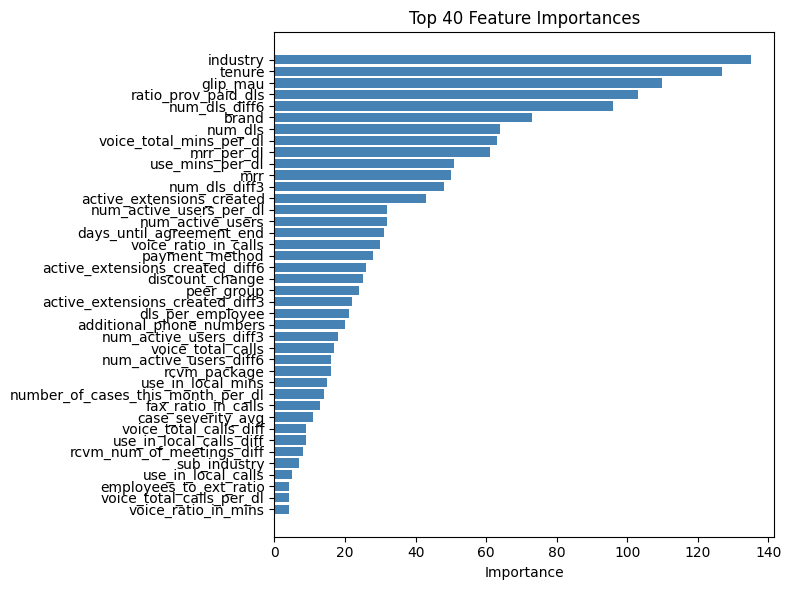

In [163]:
import matplotlib.pyplot as plt

# Get feature importance from trained model
importance = model_orig.feature_importances_

# Combine with feature names
feat_importance = pd.DataFrame({
    "feature": orig_predictors,
    "importance": importance
})

# Sort by importance descending
feat_importance = feat_importance.sort_values(by="importance", ascending=False).reset_index(drop=True)

top_n = 40  # show top 20 features

plt.figure(figsize=(8, 6))
plt.barh(
    feat_importance["feature"].iloc[:top_n][::-1],  # reverse for top-to-bottom
    feat_importance["importance"].iloc[:top_n][::-1],
    color="steelblue"
)
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances")
plt.tight_layout()
plt.show()


In [164]:
# y_test.head()

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_lift_chart(y_train, y_train_pred, y_test, y_test_pred, n_bins=10):
    def get_lift_bins(y_true, y_pred, n_bins=10):
        df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
        df = df.sort_values("y_pred", ascending=False).reset_index(drop=True)
        df["bin"] = pd.qcut(df.index, n_bins, labels=False)
        lift = df.groupby("bin")["y_true"].mean().reset_index()
        lift["bin"] = lift["bin"] + 1
        return lift
    
    lift_train = get_lift_bins(y_train, y_train_pred, n_bins)
    lift_test  = get_lift_bins(y_test, y_test_pred, n_bins)

    plt.figure(figsize=(10,6))
    bar_width = 0.4
    
    bars_train = plt.bar(
        lift_train["bin"] - bar_width/2, lift_train["y_true"], 
        width=bar_width, color="blue", alpha=0.6, label="Train"
    )
    bars_test = plt.bar(
        lift_test["bin"] + bar_width/2, lift_test["y_true"], 
        width=bar_width, color="red", alpha=0.6, label="Test"
    )

    for bar in bars_train:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f"{height:.3f}", ha="center", va="bottom", fontsize=9, color="blue")
    for bar in bars_test:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f"{height:.3f}", ha="center", va="bottom", fontsize=9, color="red")

    plt.xticks(range(1, n_bins+1))
    plt.xlabel("Decile Bin (1 = highest scores)")
    plt.ylabel("Average Actual Positive Rate")
    plt.title(f"Lift Chart ({n_bins} bins by predicted score)")
    plt.legend()
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.gca().invert_xaxis()
    plt.show()


In [166]:
def plot_lift_chart_by(
    y_train, y_train_pred,
    y_test, y_test_pred,
    n_bins=10,
    test_group=None,           # pandas Series or array aligned to y_test
    max_groups=8,              # plot at most this many groups (most frequent)
    show_train=True,           # keep overall Train bars as a baseline
    annotate=True              # print values on bars
):
    def compute_bins_index(y_pred, n_bins=10):
        """
        Return a vector of integers in 1..n_bins where 1 = highest scores.
        Uses positional ranks -> exact n_bins (no qcut/duplicates drop).
        """
        y_pred = np.asarray(y_pred)
        n = len(y_pred)
        order = np.argsort(-y_pred)                      # descending by score
        ranks = np.empty(n, dtype=int)
        ranks[order] = np.arange(n)                      # 0..n-1 (0 = highest)
        bins = (ranks * n_bins) // n + 1                 # 1..n_bins
        return bins

    def lift_by_bin(y_true, y_pred, n_bins=10):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        bins = compute_bins_index(y_pred, n_bins)
        df = pd.DataFrame({"y_true": y_true, "bin": bins})  # positional alignment
        out = (
            df.groupby("bin", as_index=False)["y_true"]
              .mean()
              .rename(columns={"y_true": "rate"})
        )
        return out

    # ---- compute lifts ----
    lift_train = lift_by_bin(y_train, y_train_pred, n_bins) if show_train else None

    # Global bins on test predictions (positional)
    y_test = np.asarray(y_test)
    y_test_pred = np.asarray(y_test_pred)
    test_bins = compute_bins_index(y_test_pred, n_bins)
    df_test = pd.DataFrame({"y_true": y_test, "bin": test_bins})

    if test_group is not None:
        tg = pd.Series(test_group).reset_index(drop=True)    # positional alignment
        # Keep top groups for readability
        grp_counts = tg.value_counts()
        chosen = grp_counts.index[:max_groups]
        df_test["group"] = tg.where(tg.isin(chosen), other="(other)")
        pivot = (
            df_test.groupby(["bin", "group"])["y_true"]
                   .mean()
                   .unstack("group")
                   .reindex(index=np.arange(1, n_bins+1), fill_value=np.nan)
                   .fillna(0.0)
        )
        # Order columns: chosen first (by frequency), "(other)" last if present
        cols = [g for g in chosen if g in pivot.columns]
        if "(other)" in pivot.columns and "(other)" not in cols:
            cols.append("(other)")
        pivot = pivot[cols]
        test_group_names = list(pivot.columns)
        lift_test_overall = (
            df_test.groupby("bin", as_index=False)["y_true"]
                   .mean()
                   .rename(columns={"y_true": "rate"})
        )
    else:
        df_test["group"] = "Overall"
        pivot = (
            df_test.groupby(["bin", "group"])["y_true"]
                   .mean()
                   .unstack("group")
                   .reindex(index=np.arange(1, n_bins+1), fill_value=np.nan)
                   .fillna(0.0)
        )
        test_group_names = ["Overall"]
        lift_test_overall = pivot.reset_index().rename(columns={"Overall": "rate"})

    # ---- plotting ----
    plt.figure(figsize=(12, 7))
    ax = plt.gca()

    x = np.arange(1, n_bins + 1)  # consistent for train & test

    # bar layout
    n_series = (1 if show_train else 0) + len(test_group_names)
    total_bar_width = 0.85
    bar_width = total_bar_width / max(n_series, 1)
    offsets = np.linspace(-total_bar_width/2 + bar_width/2,
                          total_bar_width/2 - bar_width/2, n_series) if n_series > 0 else [0.0]

    series_idx = 0

    # 1) Train overall bars (now correctly aligned)
    if show_train:
        yvals = (lift_train.set_index("bin")
                           .reindex(x)["rate"]
                           .fillna(0.0)
                           .values)
        bars = ax.bar(x + offsets[series_idx], yvals, width=bar_width, alpha=0.5, label="Train (overall)")
        if annotate:
            for b in bars:
                h = b.get_height()
                ax.text(b.get_x() + b.get_width()/2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)
        series_idx += 1

    # 2) Test groups bars
    for g in test_group_names:
        yvals = pivot[g].reindex(x).fillna(0.0).values
        bars = ax.bar(x + offsets[series_idx], yvals, width=bar_width, alpha=0.8, label=f"Test – {g}")
        if annotate:
            for b in bars:
                h = b.get_height()
                ax.text(b.get_x() + b.get_width()/2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)
        series_idx += 1

    # cosmetics
    ax.set_xticks(x)
    ax.set_xlabel("Decile Bin (1 = highest scores)")
    ax.set_ylabel("Average Actual Positive Rate")
    ax.set_title(f"Lift Chart ({n_bins} bins by predicted score) — Test split by feature A")
    ax.grid(alpha=0.3, axis="y")
    ax.legend()
    plt.tight_layout()

    # highest scores on the RIGHT
    ax.invert_xaxis()

    plt.show()

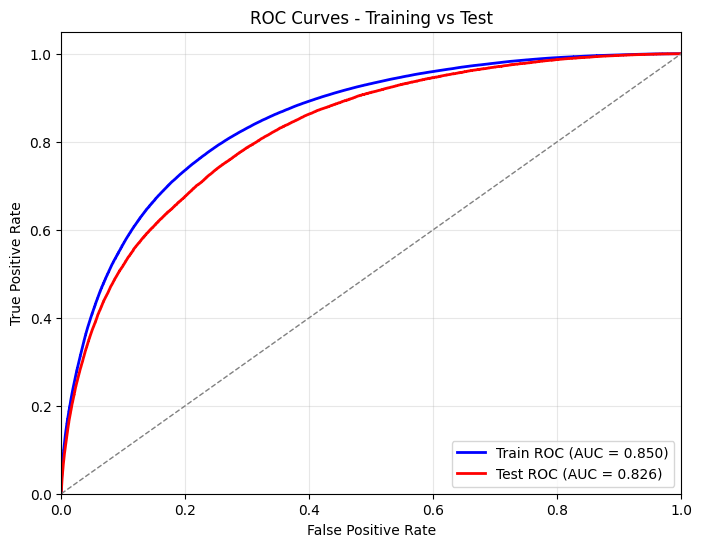

In [167]:
import matplotlib.pyplot as plt
from sklearn import metrics

# ROC curve for training set
fpr_train, tpr_train, _ = metrics.roc_curve(df_train_y['dl_upsell_target'], y_train_pred)
roc_auc_train = metrics.auc(fpr_train, tpr_train)

# ROC curve for test set
fpr_test, tpr_test, _ = metrics.roc_curve(y_test, y_predict)
roc_auc_test = metrics.auc(fpr_test, tpr_test)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, color="blue", lw=2,
         label=f"Train ROC (AUC = {roc_auc_train:.3f})")
plt.plot(fpr_test, tpr_test, color="red", lw=2,
         label=f"Test ROC (AUC = {roc_auc_test:.3f})")

# Diagonal reference line
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Training vs Test")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

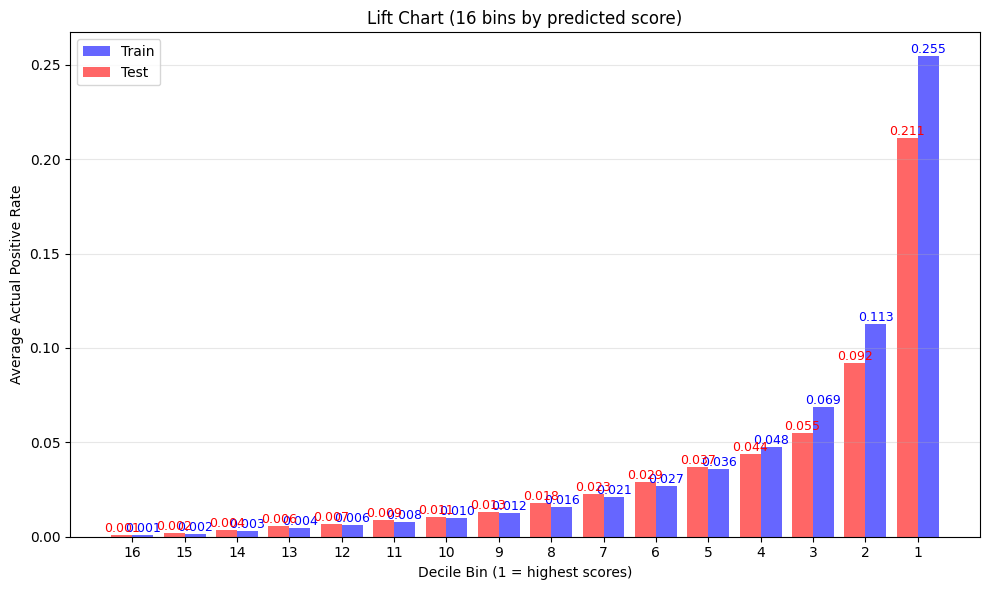

In [168]:
plot_lift_chart(
    df_train_y['dl_upsell_target'], y_train_pred,
    y_test, y_predict,
    n_bins=16
)

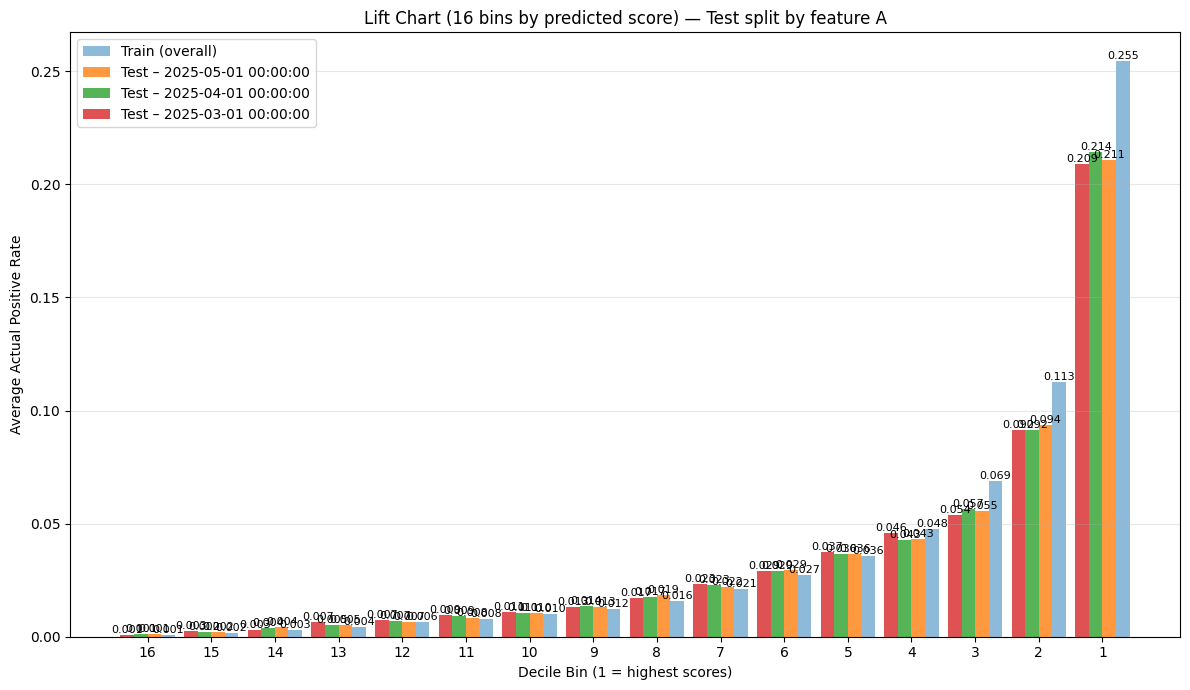

In [171]:
plot_lift_chart_by(
    df_train_y['dl_upsell_target'], y_train_pred,
    y_test, y_predict,
    n_bins=16,
    test_group=df.loc[(df['year_month']>='2025-03-01')&(df['year_month']<='2025-05-01'), 'year_month'],      # ← split test by feature A
    # max_groups=6,              # cap groups to keep chart readable
    show_train=True  
)

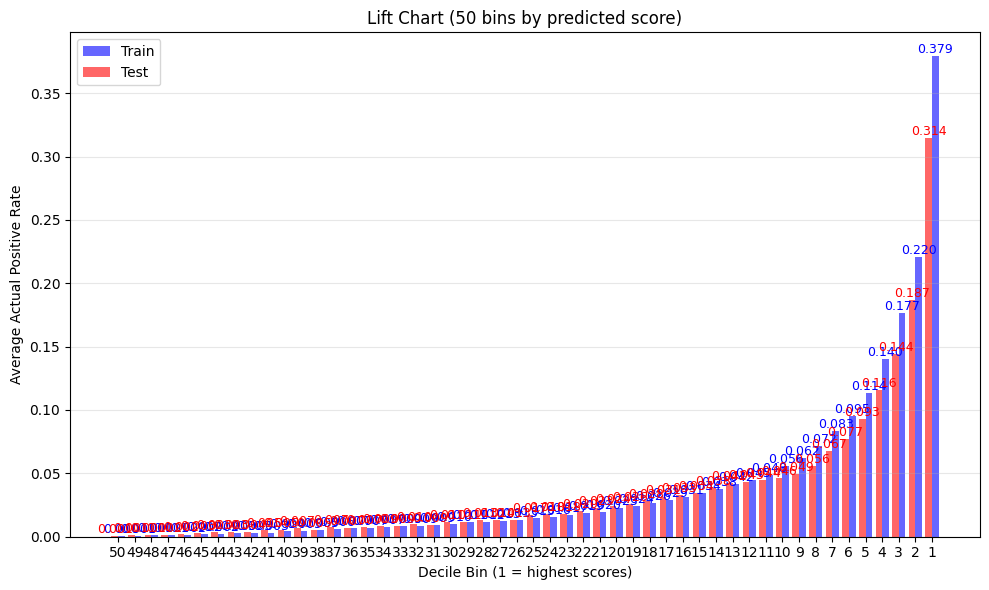

In [172]:
plot_lift_chart(
    df_train_y['dl_upsell_target'], y_train_pred,
    y_test, y_predict,
    n_bins=50
)

#  Retraining 

In [173]:
model_orig_retrained = lgb.LGBMClassifier(**model_params)

In [174]:
model_orig_retrained.fit(
    df_train_X[orig_predictors],
    df_train_y["dl_upsell_target"],
    sample_weight=df_train_X["weight_train"],
eval_set=[
    # (df_train_X.iloc[train_ind][orig_predictors],
    #  df_train_y.iloc[train_ind]["dl_upsell_target"]),
    (df_train_X[orig_predictors],
     df_train_y["dl_upsell_target"])
],
    eval_metric="auc",
    callbacks=[
        # lgb.early_stopping(stopping_rounds=20, verbose=True),
        lgb.log_evaluation(period=5)
    ],
    categorical_feature= orig_cat_predictors
)

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Info] Number of positive: 210592, number of negative: 5139124
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.694542 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11001
[LightGBM] [Info] Number of data points in the train set: 5349716, number of used features: 56
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.040351 -> initscore=-3.168949
[LightGBM] [Info] Start training from score -3.168949
[5]	valid_0's auc: 0.833431
[10]	valid_0's auc: 0.836888
[15]	va

LGBMClassifier(metric='auc', min_data_in_leaf=100, num_iterations=50,
               objective='binary', random_state=42)

In [175]:
x_test = df_test_X[orig_predictors]
y_predict = model_orig_retrained.predict_proba(x_test)[:, 1]
y_test = df_test_y['dl_upsell_target'].values

auc_score_test = metrics.roc_auc_score(y_test, y_predict)
print(f"test auc score: {auc_score_test}")

y_train_pred = model_orig_retrained.predict_proba(df_train_X[orig_predictors])[:, 1]
auc_score_train = metrics.roc_auc_score(df_train_y['dl_upsell_target'], y_train_pred)
print(f"train auc score: {auc_score_train}")


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
test auc score: 0.8258943659301101
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
train auc score: 0.8506557387138569


In [176]:
df_test_1 = df.loc[(df['year_month']>='2025-03-01')&(df['year_month']<='2025-05-01'), ['rc_account_id']+orig_predictors]

In [177]:
df_preds = pd.DataFrame({
    "y_pred_prob": y_predict,
    "y_true": y_test
}, index=df_test_X.index)

# Merge back with original data
df_test_with_preds = df_test_1[['rc_account_id']+orig_predictors].join(df_preds)


In [178]:
df_test_with_preds.shape

(1043299, 65)

In [179]:
print([x for x in df_test_with_preds.columns if 'brand' in x.lower()])

['brand']


In [180]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
def safe_auc(g):
    y = g['y_true']
    p = g['y_pred_prob']
    # Need at least one positive and one negative; otherwise AUC is undefined
    if y.nunique() < 2 or len(g) < 2:
        return np.nan
    # Drop rows with missing preds/labels
    mask = (~y.isna()) & (~p.isna())
    if mask.sum() < 2 or y[mask].nunique() < 2:
        return np.nan
    return roc_auc_score(y[mask], p[mask])

# AUC by brand
auc_by_brand = (
    df_test_with_preds
    .groupby('brand', dropna=False, as_index=False)
    .apply(safe_auc)
    .rename(columns={None: 'auc'})
)

# (Optional) add counts and positive rate for context
brand_stats = (
    df_test_with_preds
    .groupby('brand', dropna=False)
    .agg(
        n=('y_true', 'size'),
        positives=('y_true', 'sum'),
        negs=('y_true', lambda s: (1 - s).sum()),
        avg_pred=('y_pred_prob', 'mean')
    )
    .reset_index()
)
brand_stats['pos_rate'] = brand_stats['positives'] / brand_stats['n']

# Merge
auc_summary = (
    auc_by_brand.merge(brand_stats, on='brand', how='left')
    .sort_values(['auc', 'n'], ascending=[False, False])
)


In [181]:
auc_summary

,brand,auc,n,positives,negs,avg_pred,pos_rate
15,RingCentral mit Telekom,0.991935,126,2,124,0.045655,0.015873
11,RingCentral EU,0.839238,4337,217,4120,0.041932,0.050035
8,RingCentral,0.836950,864215,31144,833071,0.035245,0.036037
12,RingCentral UK,0.829051,28526,925,27601,0.028781,0.032427
10,RingCentral Canada,0.827674,53790,1751,52039,0.035159,0.032553
5,Frontier with RingCentral,0.805820,9420,103,9317,0.016367,0.010934
13,RingCentral for Symphony,0.798623,1225,48,1177,0.050574,0.039184
9,RingCentral AU,0.766434,13448,560,12888,0.042430,0.041642
22,Spectrum Enterprise Unified Communications wit...,0.744760,17251,653,16598,0.032517,0.037853
14,RingCentral mit 1&1 Connected Calls,0.738095,171,3,168,0.015216,0.017544


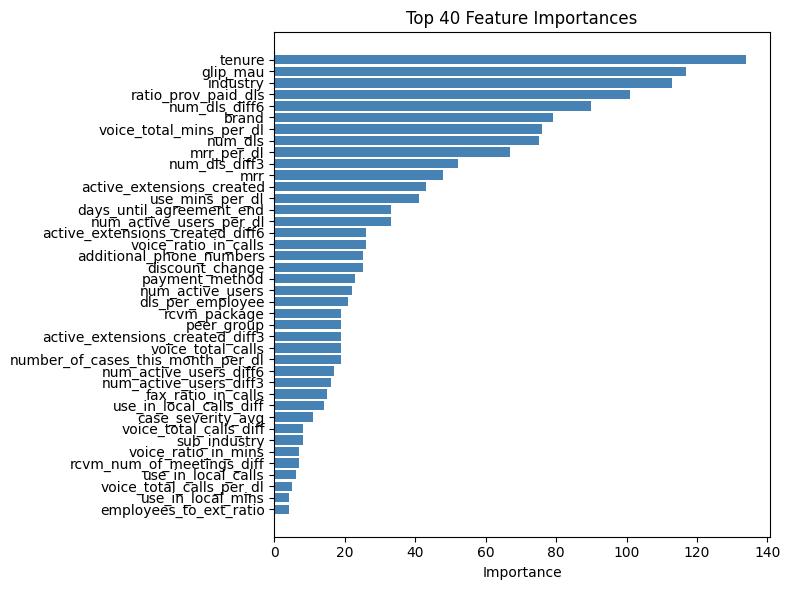

In [182]:
import matplotlib.pyplot as plt

# Get feature importance from trained model
importance = model_orig_retrained.feature_importances_

# Combine with feature names
feat_importance = pd.DataFrame({
    "feature": orig_predictors,
    "importance": importance
})

# Sort by importance descending
feat_importance = feat_importance.sort_values(by="importance", ascending=False).reset_index(drop=True)

top_n = 40  # show top 20 features

plt.figure(figsize=(8, 6))
plt.barh(
    feat_importance["feature"].iloc[:top_n][::-1],  # reverse for top-to-bottom
    feat_importance["importance"].iloc[:top_n][::-1],
    color="steelblue"
)
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances")
plt.tight_layout()
plt.show()


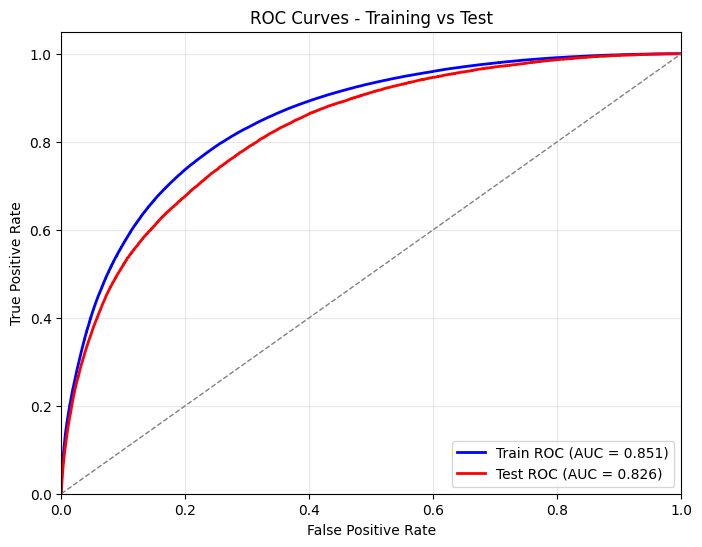

In [183]:
import matplotlib.pyplot as plt
from sklearn import metrics

# ROC curve for training set
fpr_train, tpr_train, _ = metrics.roc_curve(df_train_y['dl_upsell_target'], y_train_pred)
roc_auc_train = metrics.auc(fpr_train, tpr_train)

# ROC curve for test set
fpr_test, tpr_test, _ = metrics.roc_curve(y_test, y_predict)
roc_auc_test = metrics.auc(fpr_test, tpr_test)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, color="blue", lw=2,
         label=f"Train ROC (AUC = {roc_auc_train:.3f})")
plt.plot(fpr_test, tpr_test, color="red", lw=2,
         label=f"Test ROC (AUC = {roc_auc_test:.3f})")

# Diagonal reference line
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Training vs Test")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

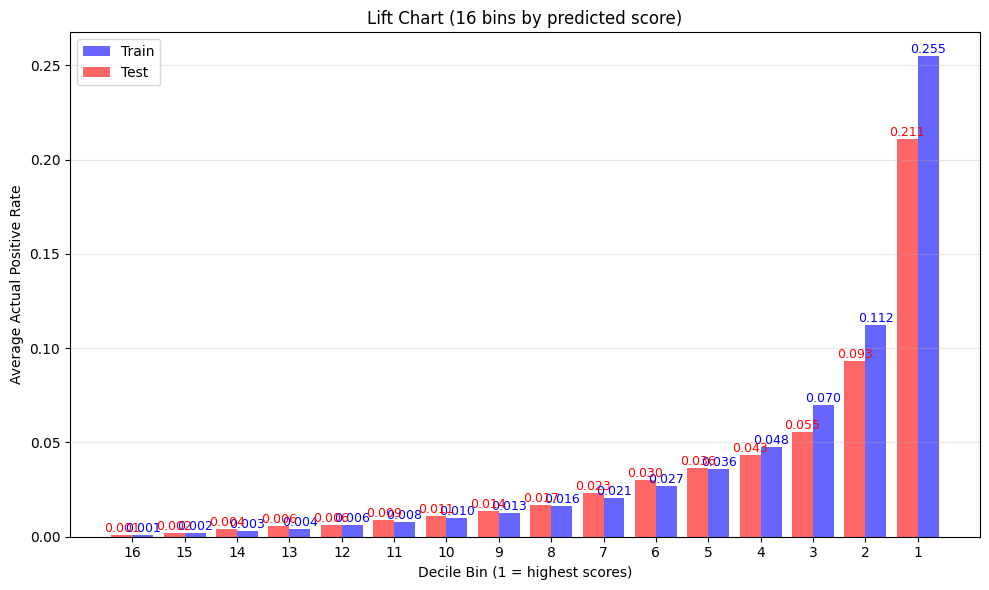

In [184]:
plot_lift_chart(
    df_train_y['dl_upsell_target'], y_train_pred,
    y_test, y_predict,
    n_bins=16
)

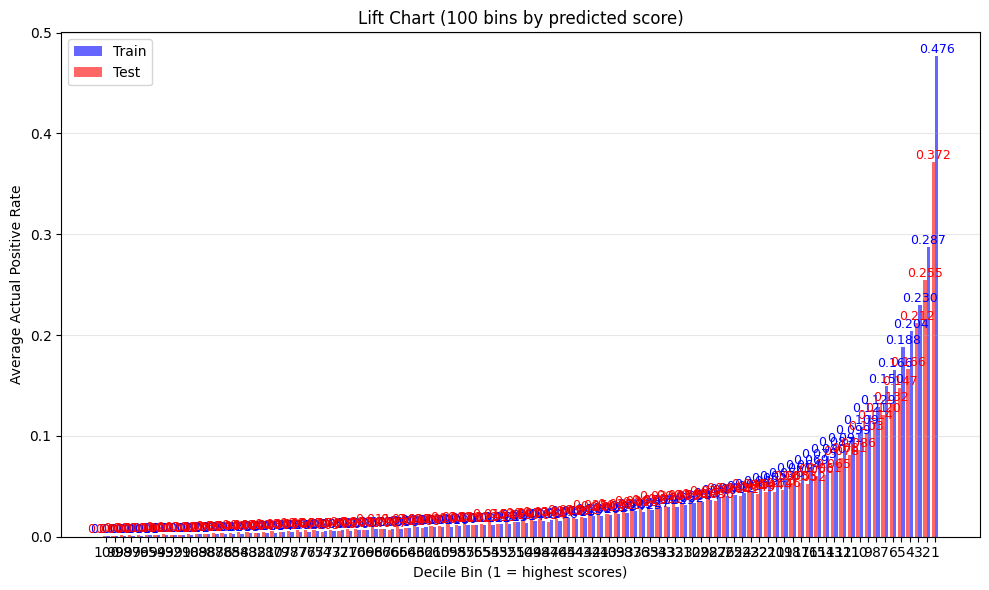

In [185]:
plot_lift_chart(
    df_train_y['dl_upsell_target'], 
    y_train_pred,
    y_test, 
    y_predict,
    n_bins=100
)

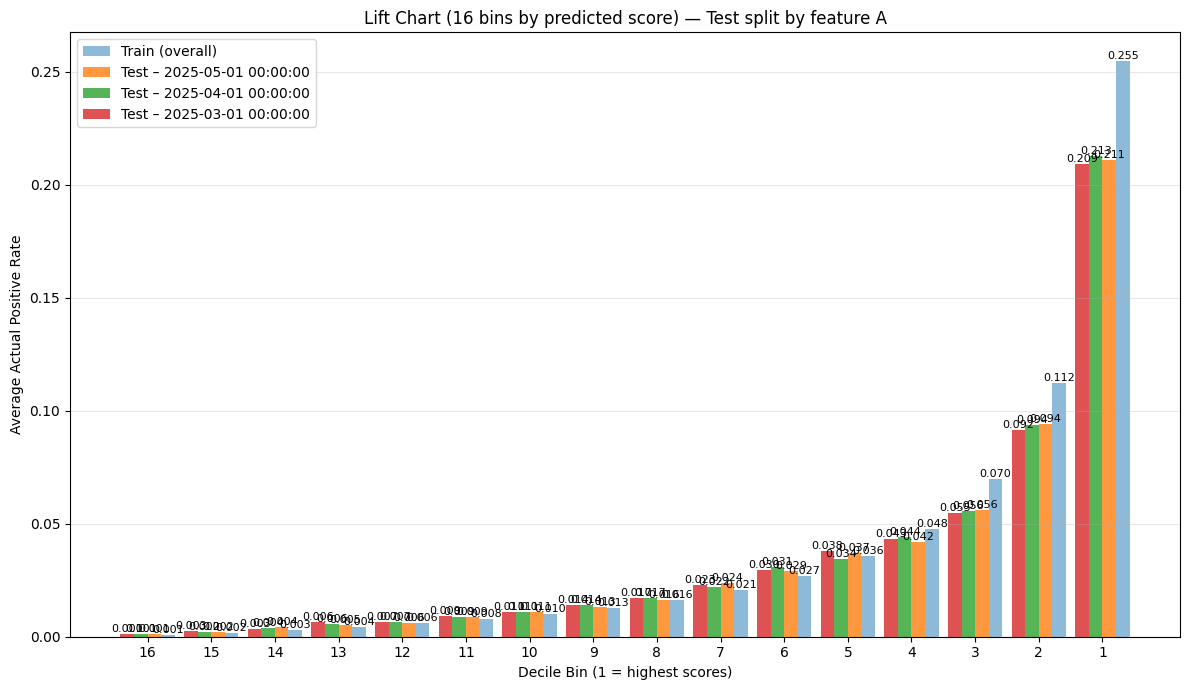

In [186]:
plot_lift_chart_by(
    df_train_y['dl_upsell_target'], y_train_pred,
    y_test, y_predict,
    n_bins=16,
    test_group=df.loc[(df['year_month']>='2025-03-01')&(df['year_month']<='2025-05-01'), 'year_month'],      # ← split test by feature A
    # max_groups=6,              # cap groups to keep chart readable
    show_train=True  
)

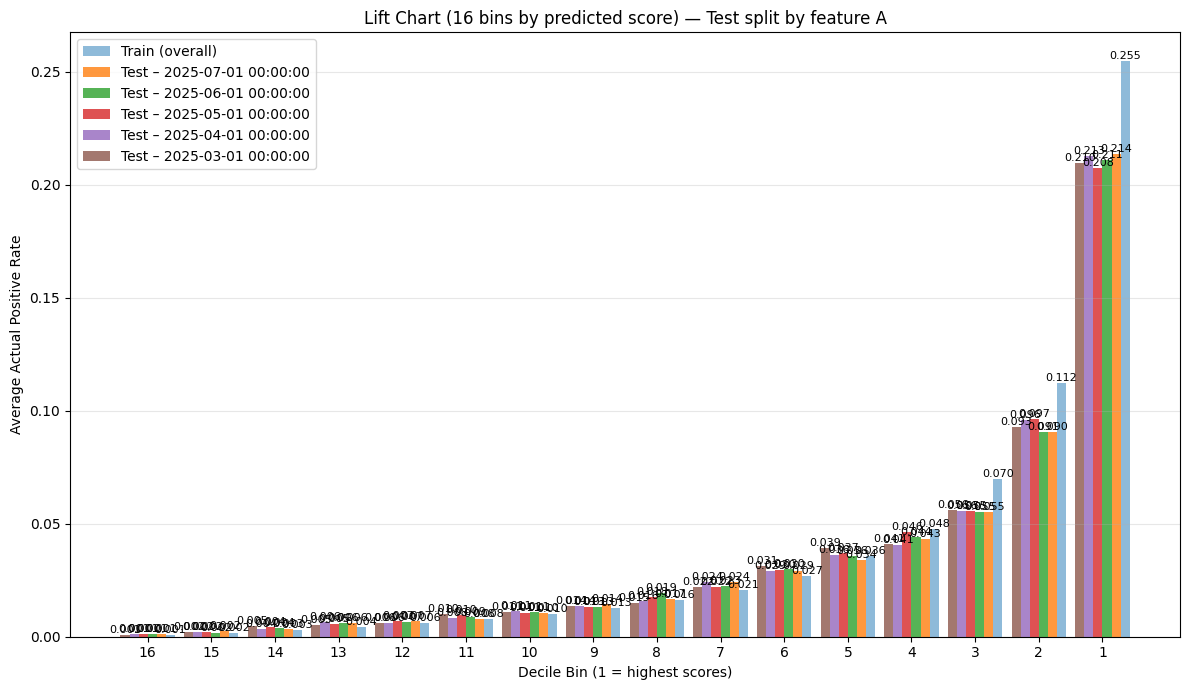

In [187]:
plot_lift_chart_by(
    df_train_y['dl_upsell_target'], y_train_pred,
    y_test, y_predict,
    n_bins=16,
    test_group=df.loc[(df['year_month']>='2025-03-01')&(df['year_month']<='2025-07-01'), 'year_month'],      # ← split test by feature A
    # max_groups=6,              # cap groups to keep chart readable
    show_train=True  
)